In [1]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

path0315 = Path('/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5_cargo_radius0.315')
path059 = Path('/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5_cargo_radius0.59')

datas = []
rs = [0.315, 0.59]

for path in [path0315, path059]:
    zarr_path = path / 'cargo_msd_seeds.zarr'
    data = zarr.open_array(zarr_path, mode='r')
    datas.append(data)

plt.style.use('../../my_style.mplstyle')

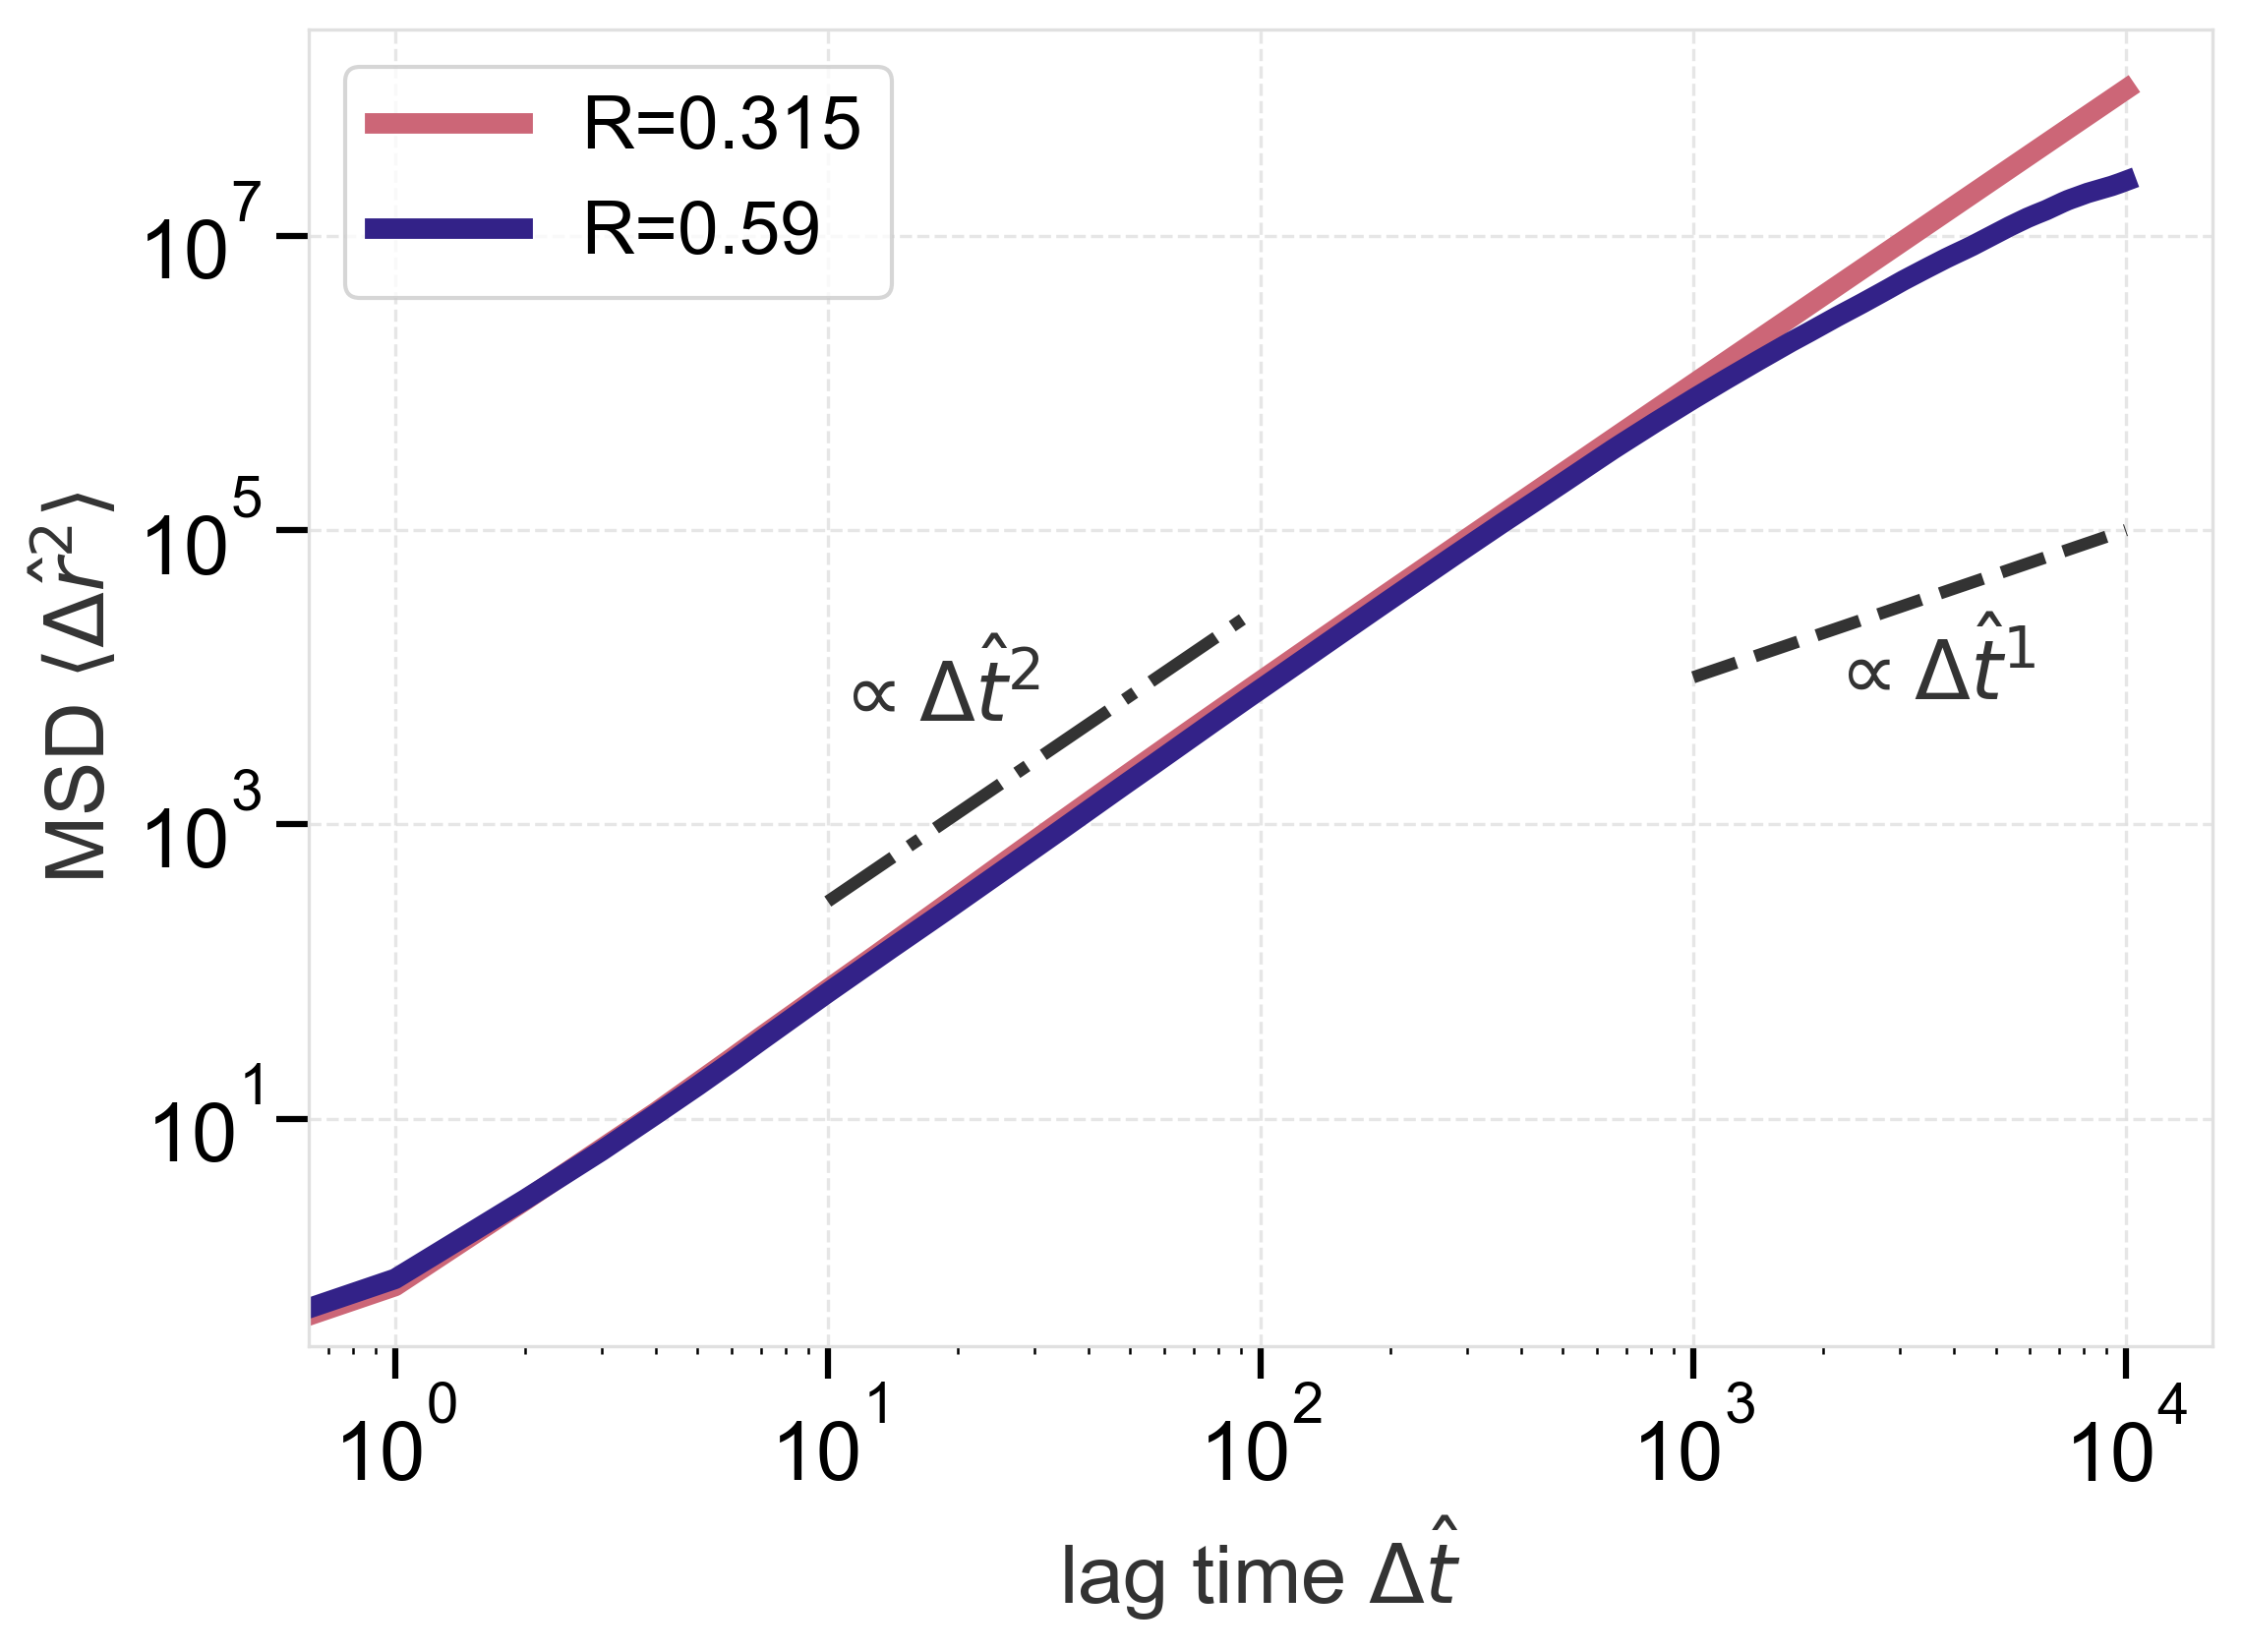

In [3]:
length = datas[0].shape[1]
t = np.arange(length)
fig, ax = plt.subplots()

"""
for i in range(data.shape[0]):
    ax.plot(t, data[i, :], alpha=0.01, color="#333333")
"""
for i in range(len(datas)):
    ax.plot(t, np.mean(datas[i], axis=0), label=f"R={rs[i]}", lw=5)

t1 = np.arange(1e3, 1e4)
t2 = np.arange(1e1, 1e2)

y1 = 1.0e1 * t1 ** 1.0
y2 = 3.0e-0 * t2 ** 2.0

ax.plot(t1, y1, c = '#333333', linestyle = '--')
ax.plot(t2, y2, c = '#333333', linestyle = '-.')

ax.text(2e3, 7e3, r'$\propto \Delta \hat{t}^{1}$', color='#333333')
ax.text(1e1, 5e3, r'$\propto \Delta \hat{t}^{2}$', color='#333333')

ax.legend()

ax.set(
    #xlim=(1e0, 1e4),
    #ylim=(1e-1, 1e8),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta \hat{t}$',
    ylabel='MSD $\\langle \\Delta \\hat{r}^2 \\rangle$'
    )


cd=Path.cwd()

fig.savefig(cd/"figure/MSD.png", bbox_inches='tight')
fig.savefig(cd/"figure/MSD.pdf", bbox_inches='tight')
